# oil-price-pgm

**Author:** Sana Ur Rehman Arain

**Profession:** Data Scientist | Data Analyst  

**Created:** June 2026  

---

## Copyright & Usage Notice

This project is an original work created by **Sana Ur Rehman Arain** for educational purposes, 
professional portfolio development, and showcasing data science skills.

You may view this project for learning and reference purposes. However, 
you may not copy, reproduce, redistribute, publish, or claim this work as 
your own without explicit permission and proper **credit** to the author.

If you use any part of this project, please provide appropriate attribution.

© 2026 Sana Ur Rehman Arain. All rights reserved.

## Citation

If you reference or build upon this project, please provide appropriate
credit to the original author.

For citation information, see the project's README and CITATION.cff file.

In [1]:
import os
from dotenv import load_dotenv
from fredapi import Fred

# Load environment variables from the .env file
load_dotenv()

# Retrieve the key securely
fred_key = os.getenv('FRED_API_KEY')

# Initialize the FRED API
if fred_key is None:
    raise ValueError("API key not found. Please check your .env file.")
else:
    fred = Fred(api_key=fred_key)
    print("FRED API initialized successfully.")

FRED API initialized successfully.


In [2]:
import pgmpy.estimators as est

print([x for x in dir(est) if "BIC" in x or "K2" in x or "Score" in x])

['BIC', 'BICCondGauss', 'BICGauss', 'K2', 'ScoreCache', 'StructureScore']


c:\Users\Yahya\anaconda3\envs\myenv\Lib\site-packages\pgmpy\estimators\__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in v1.3.0. Use `pgmpy.structure_score` instead.
  from .StructureScore import (


In [3]:
import warnings
import datetime

# Data Manipulation & Math
import pandas as pd
import numpy as np
from scipy.stats import zscore

# Data APIs & Environment
import yfinance as yf

# Visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from matplotlib.collections import LineCollection
from matplotlib.colors import ListedColormap, BoundaryNorm
import seaborn as sns
import networkx as nx
from pandas.plotting import autocorrelation_plot

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Step 3, 4, 5, & 6: DATA IMPORT, CLEANING, AND STERILIZATION

In [4]:
print("--- STEP 3: DATA IMPORT & STRUCTURING ---")

# ==========================================
# 1. FRED DATA
# ==========================================

fred_series = {
    'WTISPLC': 'WTI_Oil_Price',
    'INDPRO': 'Industrial_Production',
    'CPIENGSL': 'CPI_Energy',
    'CAPUTLG211S': 'Cap_Util_Oil_Gas'
}

fred_list = []

for series_id, name in fred_series.items():

    s = fred.get_series(series_id)
    s.name = name

    s.index = (
        pd.to_datetime(s.index)
        .to_period('M')
        .to_timestamp()
    )

    fred_list.append(s)

df_fred = pd.concat(fred_list, axis=1)

# ==========================================
# 2. YAHOO FINANCE DATA
# ==========================================

yf_tickers = {
    '^GSPC': 'SP500',
    'DX-Y.NYB': 'USD_Index',
    'XLE': 'Energy_Sector_ETF'
}

yf_list = []

for ticker, name in yf_tickers.items():

    print(f"Downloading {ticker}...")

    data = yf.download(
        ticker,
        period="max",
        interval="1mo",
        auto_adjust=False,
        progress=False
    )

    if data.empty:
        print(f"Warning: No data for {ticker}")
        continue

    if isinstance(data.columns, pd.MultiIndex):
        series = data["Close"].iloc[:, 0]
    else:
        series = data["Close"]

    series.name = name

    series.index = (
        pd.to_datetime(series.index)
        .to_period('M')
        .to_timestamp()
    )

    yf_list.append(series)

df_yf = pd.concat(yf_list, axis=1)

# ==========================================
# 3. MERGE DATASETS
# ==========================================

print("\nMerging datasets...")

df_master = pd.concat(
    [df_fred, df_yf],
    axis=1,
    join="outer"
)

df_master = df_master.loc["2000-01-01":]

df_raw = df_master.copy()

# ==========================================
# STEP 5: DATA CLEANING
# ==========================================

print("\n--- STEP 5: DATA CLEANING ---")

missing_before = df_master.isna().sum().sum()

print(f"Missing values before cleaning: {missing_before}")

# Time interpolation
df_master = df_master.interpolate(method='time')

# Forward fill
df_master = df_master.ffill()

# Backward fill
df_master = df_master.bfill()

missing_after = df_master.isna().sum().sum()

print(f"Missing values after cleaning: {missing_after}")

# ==========================================
# OUTLIER DETECTION (IQR METHOD) FOR ALL COLUMNS
# ==========================================

print("\n--- OUTLIER CHECK ---")
outlier_dict = {}
outlier_rows_dict = {}  

for col in df_master.columns:
    Q1 = df_master[col].quantile(0.25)
    Q3 = df_master[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_master[(df_master[col] < lower_bound) | (df_master[col] > upper_bound)]
    outlier_dict[col] = len(outliers)
    outlier_rows_dict[col] = outliers[[col]]  # keep dates + values for inspection

print("Anomalous Outliers Detected per Variable:")
for key, value in outlier_dict.items():
    print(f" - {key}: {value}")

# ==========================================
# STEP 6: STERILIZED DATASET
# ==========================================

df_sterilized = df_master.copy()

print("\n--- STEP 6: STERILIZED DATASET ---")

print(f"Shape: {df_sterilized.shape}")

print(df_sterilized.head())

print("\nUnique Values:")
print(df_sterilized.nunique())

--- STEP 3: DATA IMPORT & STRUCTURING ---

Merging datasets...

--- STEP 5: DATA CLEANING ---
Missing values before cleaning: 8
Missing values after cleaning: 0

--- OUTLIER CHECK ---
Anomalous Outliers Detected per Variable:
 - WTI_Oil_Price: 0
 - Industrial_Production: 0
 - CPI_Energy: 0
 - Cap_Util_Oil_Gas: 10
 - SP500: 22
 - USD_Index: 0
 - Energy_Sector_ETF: 0

--- STEP 6: STERILIZED DATASET ---
Shape: (319, 7)
            WTI_Oil_Price  Industrial_Production  CPI_Energy  \
2000-01-01          27.18                91.5380       115.0   
2000-02-01          29.35                91.8239       118.8   
2000-03-01          29.89                92.1504       124.3   
2000-04-01          25.74                92.6989       120.9   
2000-05-01          28.78                92.9499       120.0   

            Cap_Util_Oil_Gas        SP500   USD_Index  Energy_Sector_ETF  
2000-01-01           94.1056  1394.459961  105.129997          13.656250  
2000-02-01           94.0535  1366.420044  10

In [5]:
# ==========================================
# OUTLIER INSPECTION
# ==========================================
print("--- OUTLIER INSPECTION ---\n")
for col, rows in outlier_rows_dict.items():
    if len(rows) > 0:
        print(f"{col} ({len(rows)} flagged points):")
        print(rows)
        print()

--- OUTLIER INSPECTION ---

Cap_Util_Oil_Gas (10 flagged points):
            Cap_Util_Oil_Gas
2005-09-01           78.2684
2005-10-01           81.2026
2005-11-01           86.0280
2005-12-01           87.1499
2008-09-01           78.3826
2020-05-01           78.6832
2020-06-01           84.5198
2020-08-01           85.5080
2020-10-01           84.4264
2021-02-01           79.9949

SP500 (22 flagged points):
                  SP500
2024-08-01  5648.399902
2024-09-01  5762.479980
2024-10-01  5705.450195
2024-11-01  6032.379883
2024-12-01  5881.629883
2025-01-01  6040.529785
2025-02-01  5954.500000
2025-05-01  5911.689941
2025-06-01  6204.950195
2025-07-01  6339.390137
2025-08-01  6460.259766
2025-09-01  6688.459961
2025-10-01  6840.200195
2025-11-01  6849.089844
2025-12-01  6845.500000
2026-01-01  6939.029785
2026-02-01  6878.879883
2026-03-01  6528.520020
2026-04-01  7209.009766
2026-05-01  7580.060059
2026-06-01  7499.359863
2026-07-01  7483.240234



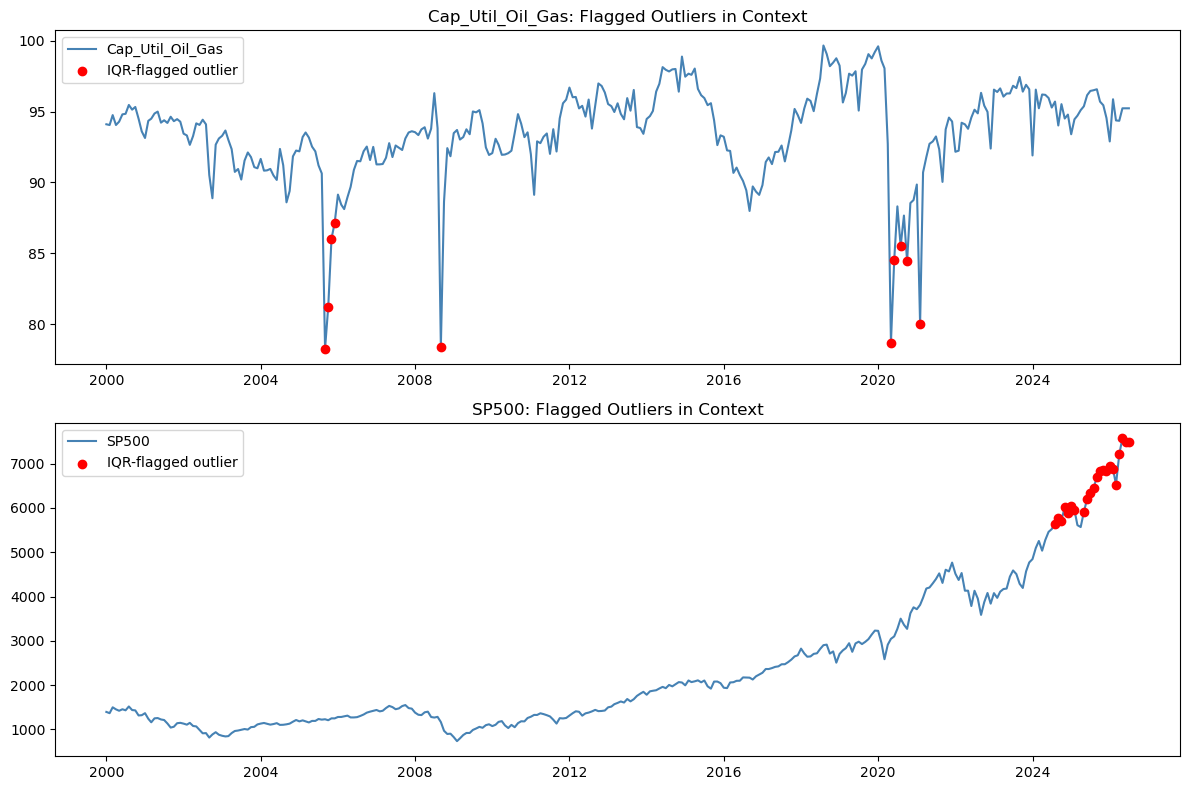

In [6]:
# ==========================================
# OUTLIER VISUALIZATION 
# ==========================================
flagged_cols = [col for col, rows in outlier_rows_dict.items() if len(rows) > 0]

fig, axes = plt.subplots(len(flagged_cols), 1, figsize=(12, 4 * len(flagged_cols)))
if len(flagged_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, flagged_cols):
    ax.plot(df_master.index, df_master[col], color="steelblue", label=col)
    ax.scatter(
        outlier_rows_dict[col].index,
        outlier_rows_dict[col][col],
        color="red", zorder=5, label="IQR-flagged outlier"
    )
    ax.set_title(f"{col}: Flagged Outliers in Context")
    ax.legend()

plt.tight_layout()
plt.show()

In [7]:
# ==========================================
# OUTLIER JUSTIFICATION AND RETAIN/REMOVE DECISION
# ==========================================
# SP500:
# All flagged observations occur during 2024-2026,
# corresponding to recent record market highs.
# Because IQR is applied to raw non-stationary price levels,
# these observations reflect the long-term upward trend
# rather than anomalous or erroneous data.
# Therefore, the observations are retained.
# crash/recovery). These are genuine market shocks, not data errors -> RETAIN.

# Cap_Util_Oil_Gas: flagged points correspond to real supply-side disruptions
# (e.g. 2008 demand collapse, 2020 shut-ins). Genuine, not erroneous -> RETAIN.
#
# WTI_Oil_Price, Industrial_Production, CPI_Energy, USD_Index, Energy_Sector_ETF:
# zero outliers flagged -> no decision needed.

outlier_decisions = {
    "SP500": "retain",
    "Cap_Util_Oil_Gas": "retain",
}

for col, decision in outlier_decisions.items():
    print(f"{col}: {len(outlier_rows_dict[col])} outliers flagged -> decision: {decision.upper()}")

# No removals -> sterilized dataset keeps all rows. This line makes that explicit
# in code rather than leaving it implicit.
# df_sterilized = df_master.copy()  # outliers retained per justification above; see printout

SP500: 22 outliers flagged -> decision: RETAIN
Cap_Util_Oil_Gas: 10 outliers flagged -> decision: RETAIN


In [8]:
# ==========================================
# TRIM TO LAST FULLY AVAILABLE OBSERVATION
# ==========================================

last_valid_dates = df_raw.apply(lambda col: col.last_valid_index())

last_common_date = last_valid_dates.min()

df_sterilized = df_sterilized.loc[:last_common_date]

print("Last common valid date:", last_common_date)

Last common valid date: 2026-05-01 00:00:00


In [9]:
print(df_sterilized.tail())

            WTI_Oil_Price  Industrial_Production  CPI_Energy  \
2026-01-01          60.04               101.1235     281.436   
2026-02-01          64.51               101.9493     283.223   
2026-03-01          91.38               101.6273     314.019   
2026-04-01         100.32               102.5090     325.978   
2026-05-01         102.13               102.6475     338.639   

            Cap_Util_Oil_Gas        SP500  USD_Index  Energy_Sector_ETF  
2026-01-01           92.8946  6939.029785  96.989998          51.049999  
2026-02-01           95.8714  6878.879883  97.610001          55.919998  
2026-03-01           94.3768  6528.520020  99.959999          61.259998  
2026-04-01           94.3523  7209.009766  98.080002          59.650002  
2026-05-01           95.2336  7580.060059  98.910004          56.290001  


In [10]:
print("\nLatest observations:")

print(df_sterilized.tail(3))

print("\nRows with duplicated values:")

print(
    df_sterilized[
        df_sterilized.eq(df_sterilized.shift()).all(axis=1)
    ]
)


Latest observations:
            WTI_Oil_Price  Industrial_Production  CPI_Energy  \
2026-03-01          91.38               101.6273     314.019   
2026-04-01         100.32               102.5090     325.978   
2026-05-01         102.13               102.6475     338.639   

            Cap_Util_Oil_Gas        SP500  USD_Index  Energy_Sector_ETF  
2026-03-01           94.3768  6528.520020  99.959999          61.259998  
2026-04-01           94.3523  7209.009766  98.080002          59.650002  
2026-05-01           95.2336  7580.060059  98.910004          56.290001  

Rows with duplicated values:
Empty DataFrame
Columns: [WTI_Oil_Price, Industrial_Production, CPI_Energy, Cap_Util_Oil_Gas, SP500, USD_Index, Energy_Sector_ETF]
Index: []


In [11]:
# ==========================================
# STATIONARY DATASET CREATION
# ==========================================

print("\n--- STATIONARY DATASET CREATION ---")

df_stationary = np.log(df_sterilized).diff()

df_stationary.dropna(inplace=True)

print(df_stationary.shape)

print(df_stationary.head())


--- STATIONARY DATASET CREATION ---
(316, 7)
            WTI_Oil_Price  Industrial_Production  CPI_Energy  \
2000-02-01       0.076811               0.003118    0.032509   
2000-03-01       0.018231               0.003549    0.045257   
2000-04-01      -0.149478               0.005935   -0.027734   
2000-05-01       0.111634               0.002704   -0.007472   
2000-06-01       0.100729               0.000390    0.055119   

            Cap_Util_Oil_Gas     SP500  USD_Index  Energy_Sector_ETF  
2000-02-01         -0.000554 -0.020313   0.007486          -0.043256  
2000-03-01          0.007415  0.092324  -0.004542           0.113926  
2000-04-01         -0.007410 -0.031280   0.043610          -0.015038  
2000-05-01          0.002521 -0.022159  -0.012793           0.111026  
2000-06-01          0.005434  0.023652  -0.017627          -0.061412  


### Augmented Dickey-Fuller (ADF) test

In [12]:
# ==========================================
# ADF STATIONARITY TEST
# ==========================================

from statsmodels.tsa.stattools import adfuller

adf_results = []

for col in df_stationary.columns:

    result = adfuller(df_stationary[col])

    adf_results.append([
        col,
        result[0],
        result[1],
        "Yes" if result[1] < 0.05 else "No"
    ])

adf_df = pd.DataFrame(
    adf_results,
    columns=[
        "Variable",
        "ADF Statistic",
        "P-Value",
        "Stationary (<0.05)"
    ]
)

display(adf_df)

,Variable,ADF Statistic,P-Value,Stationary (<0.05)
0,WTI_Oil_Price,-10.597265,6.302558e-19,Yes
1,Industrial_Production,-13.562473,2.295928e-25,Yes
2,CPI_Energy,-12.361777,5.525907e-23,Yes
3,Cap_Util_Oil_Gas,-13.937054,4.969138e-26,Yes
4,SP500,-17.195808,6.507669e-30,Yes
5,USD_Index,-16.883156,1.059057e-29,Yes
6,Energy_Sector_ETF,-18.789842,2.023548e-30,Yes


In [13]:
print(result)

(np.float64(-18.78984167146198), np.float64(2.0235482234851543e-30), 0, 315, {'1%': np.float64(-3.451281394993741), '5%': np.float64(-2.8707595072926293), '10%': np.float64(-2.571682118921643)}, np.float64(-707.4885585685183))


# Step 7: Exploratory Data Analysis (EDA) Code

In [14]:
print("\n--- STEP 7: EXPLORATORY DATA ANALYSIS (EDA) ---")

sns.set_theme(style="whitegrid")

cols = df_stationary.columns


--- STEP 7: EXPLORATORY DATA ANALYSIS (EDA) ---


## A. SUMMARY STATISTICS

In [15]:
print("\nSummary Statistics")

display(df_stationary.describe().T)


Summary Statistics


,count,mean,std,min,25%,50%,75%,max
WTI_Oil_Price,316.0,0.004189,0.102078,-0.568125,-0.049297,0.016470,0.060863,0.545621
Industrial_Production,316.0,0.000362,0.011526,-0.141422,-0.002855,0.000884,0.004620,0.063472
CPI_Energy,316.0,0.003418,0.031422,-0.198750,-0.010708,0.003960,0.018613,0.126284
Cap_Util_Oil_Gas,316.0,0.000038,0.024784,-0.179854,-0.006941,0.000355,0.007418,0.125686
SP500,316.0,0.005358,0.044225,-0.185636,-0.017881,0.011258,0.033127,0.119421
USD_Index,316.0,-0.000193,0.022126,-0.062107,-0.014715,-0.000277,0.012519,0.074908
Energy_Sector_ETF,316.0,0.004482,0.073510,-0.443282,-0.031731,0.011347,0.042799,0.268224


## B. DISTRIBUTION PLOTS

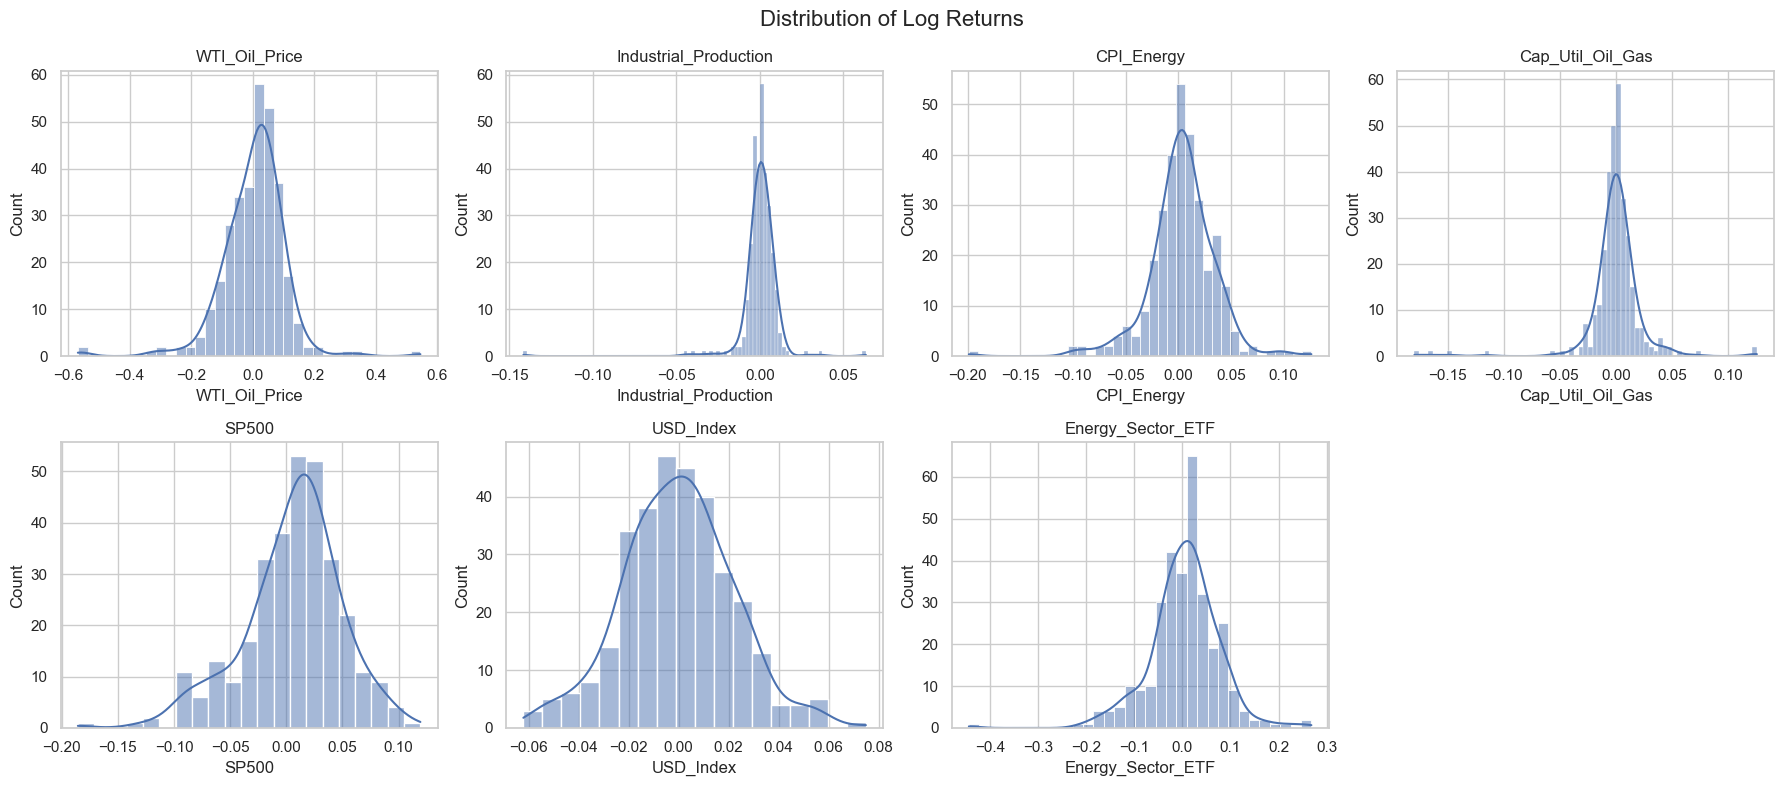

In [16]:
fig, axes = plt.subplots(
    2,
    4,
    figsize=(18,8)
)

fig.suptitle(
    "Distribution of Log Returns",
    fontsize=16
)

axes = axes.flatten()

for i, col in enumerate(cols):

    sns.histplot(
        df_stationary[col],
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(col)

axes[-1].axis("off")

plt.tight_layout()
plt.show()

## C. BOXPLOTS (OUTLIER VISUALIZATION)

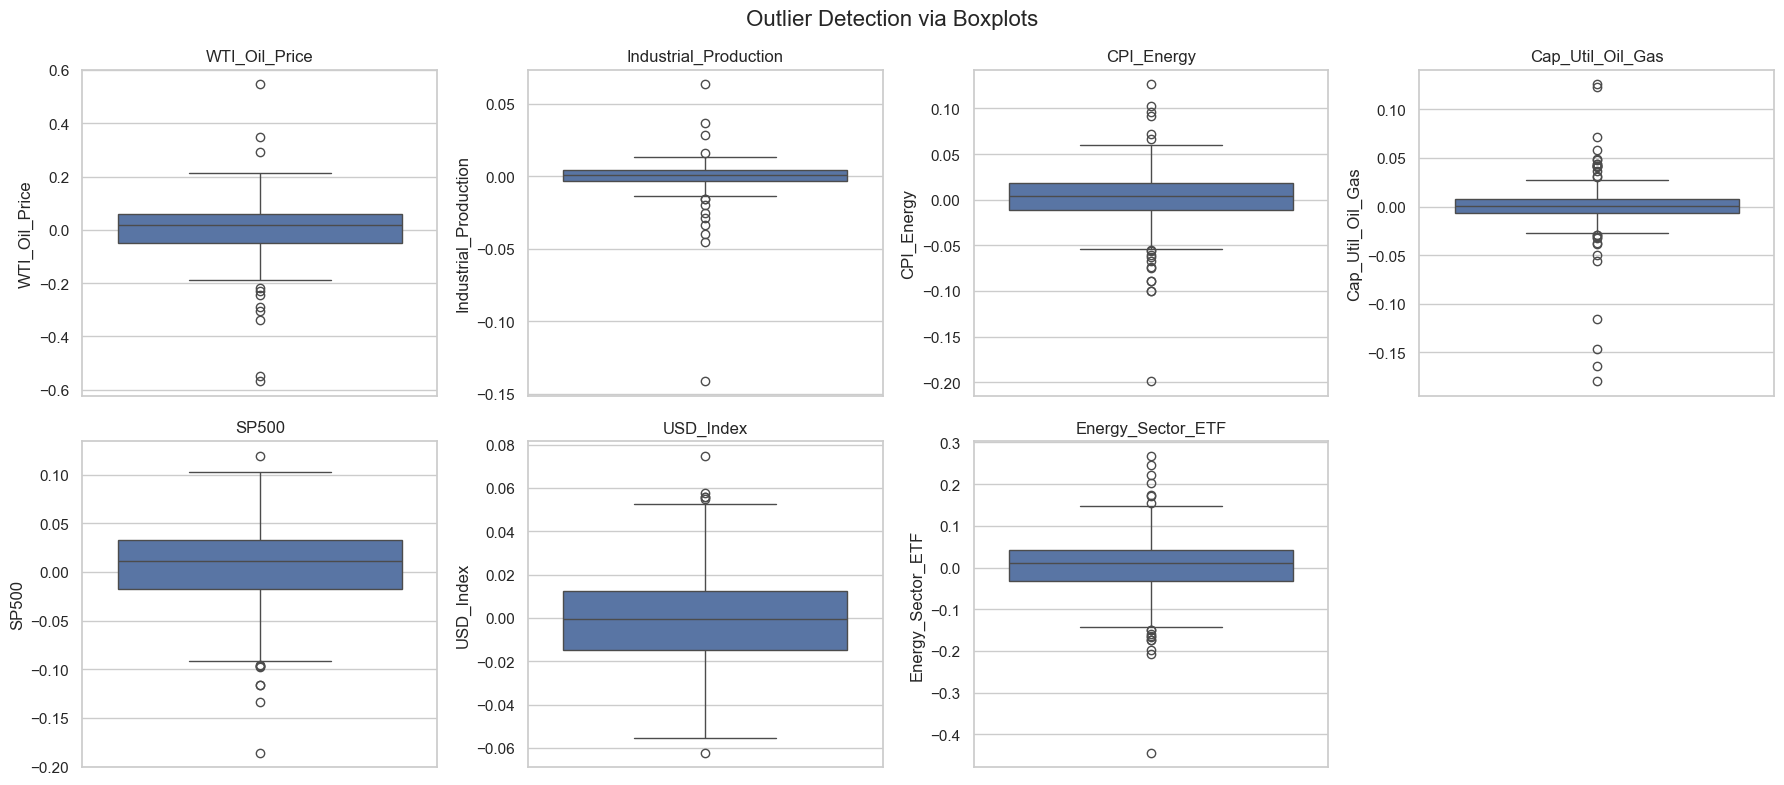

In [17]:
fig, axes = plt.subplots(
    2,
    4,
    figsize=(18,8)
)

fig.suptitle(
    "Outlier Detection via Boxplots",
    fontsize=16
)

axes = axes.flatten()

for i, col in enumerate(cols):

    sns.boxplot(
        y=df_stationary[col],
        ax=axes[i]
    )

    axes[i].set_title(col)

axes[-1].axis("off")

plt.tight_layout()
plt.show()

## D. TIME SERIES PLOTS

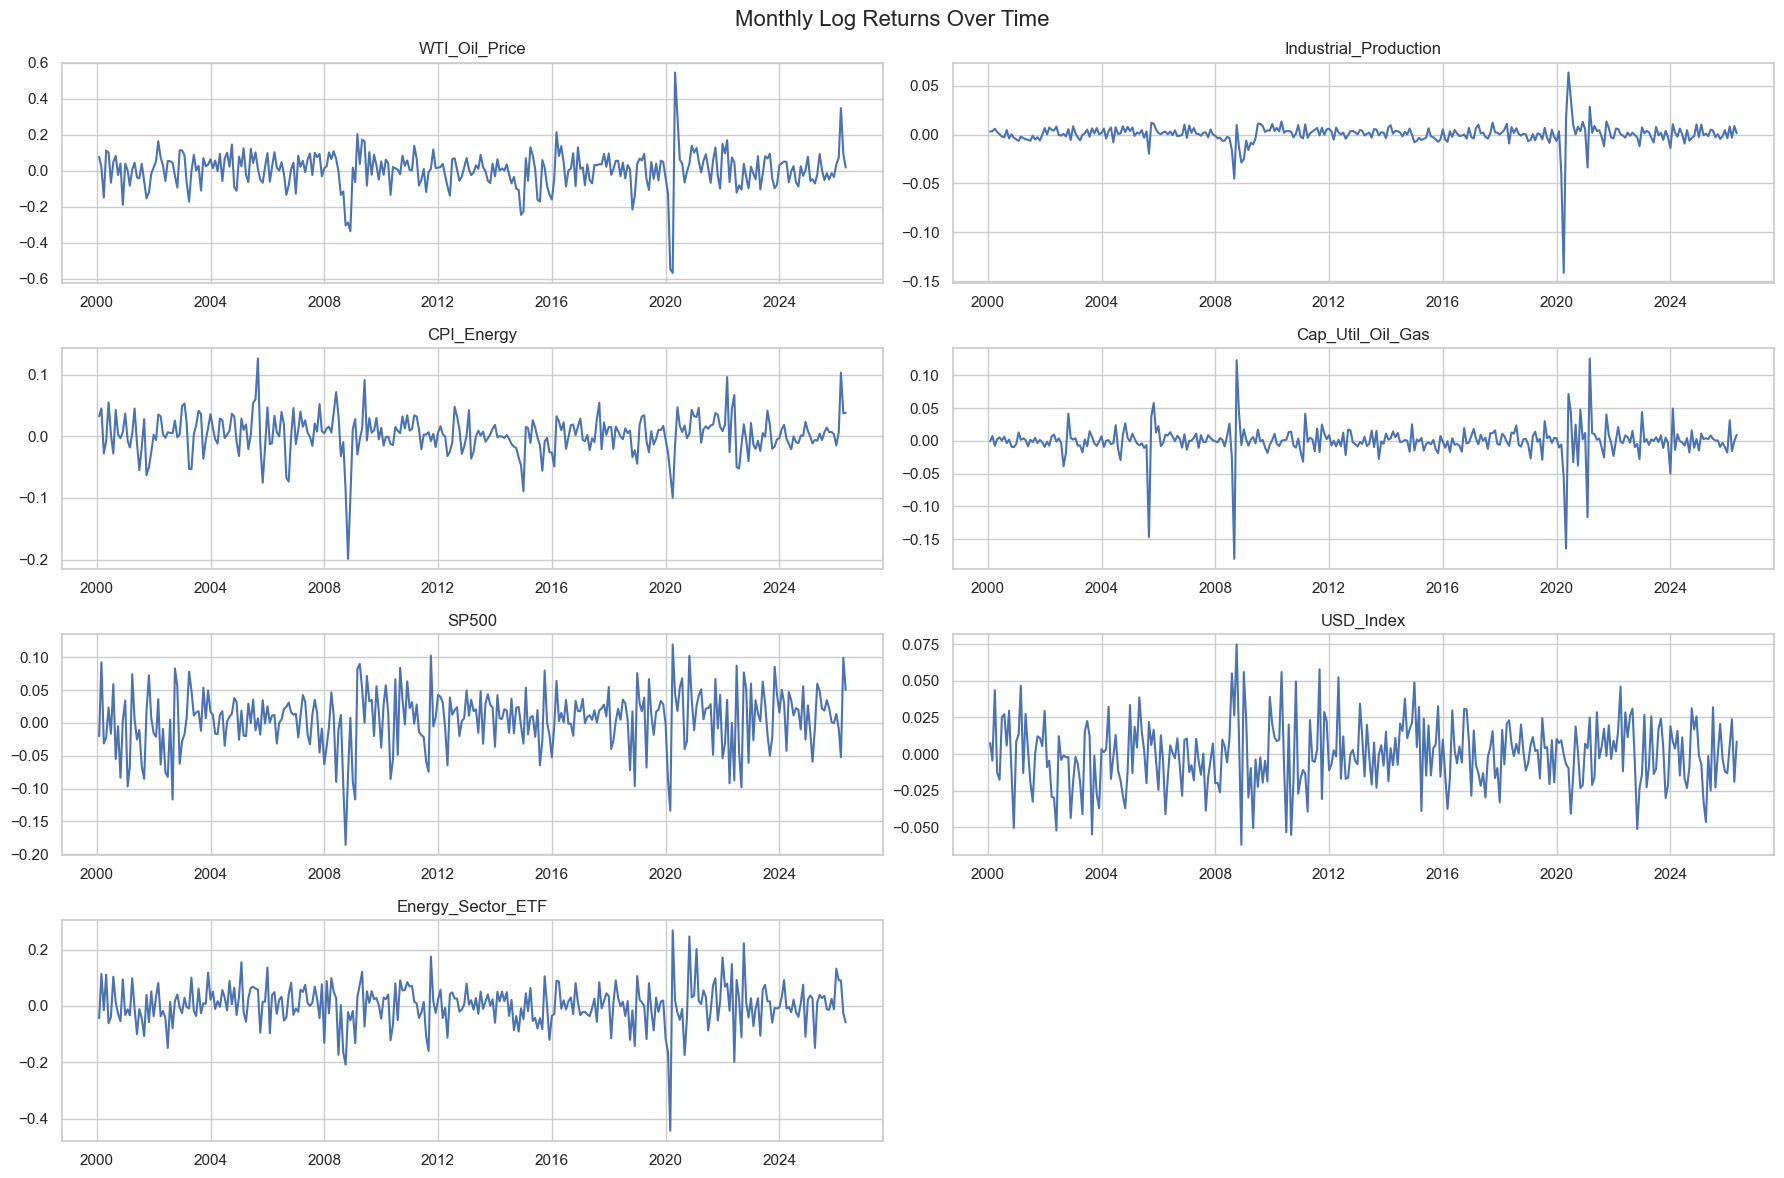

In [18]:
fig, axes = plt.subplots(
    4,
    2,
    figsize=(18,12)
)

fig.suptitle(
    "Monthly Log Returns Over Time",
    fontsize=16
)

axes = axes.flatten()

for i, col in enumerate(cols):

    axes[i].plot(
        df_stationary.index,
        df_stationary[col]
    )

    axes[i].set_title(col)

axes[-1].axis("off")

plt.tight_layout()
plt.show()

## E. CORRELATION HEATMAP

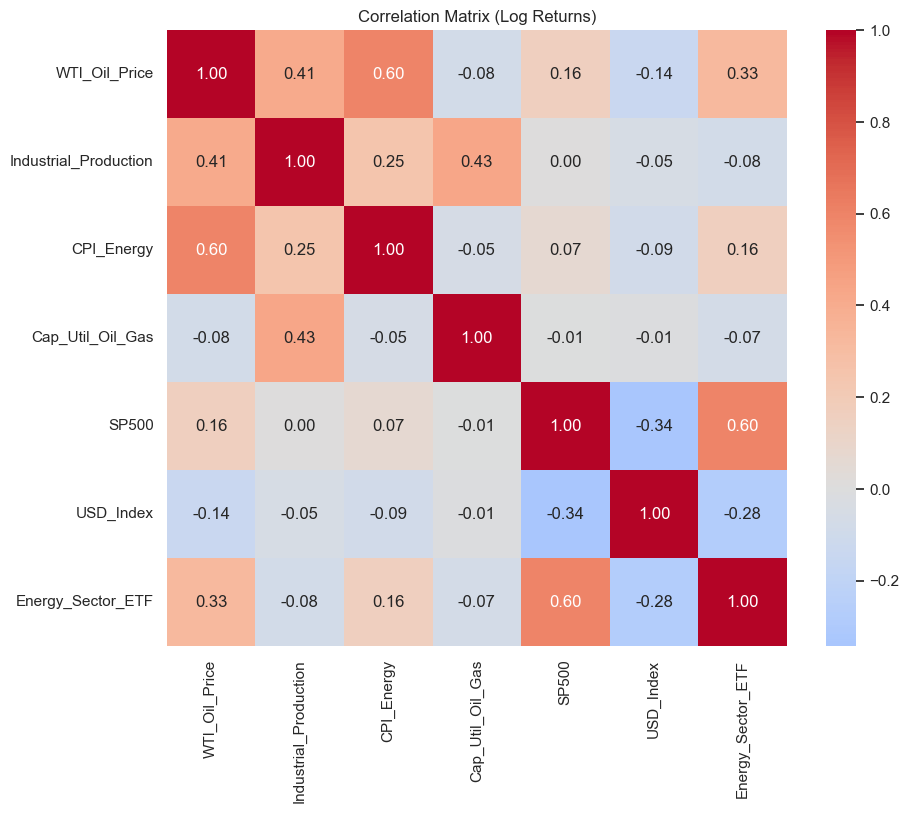

In [19]:
plt.figure(figsize=(10,8))

corr_matrix = df_stationary.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    center=0
)

plt.title(
    "Correlation Matrix (Log Returns)"
)

plt.show()

## F. AUTOCORRELATION OF WTI RETURNS

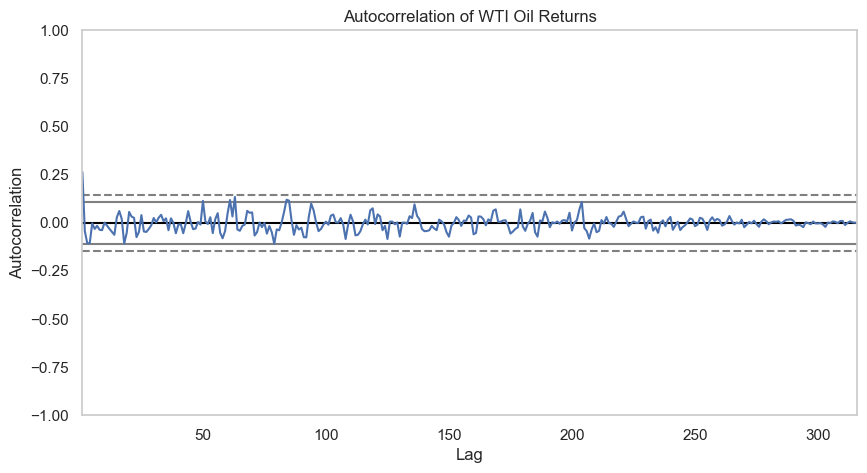

In [20]:
plt.figure(figsize=(10,5))

autocorrelation_plot(
    df_stationary["WTI_Oil_Price"]
)

plt.title(
    "Autocorrelation of WTI Oil Returns"
)

plt.show()

## G. PAIRWISE RELATIONSHIPS

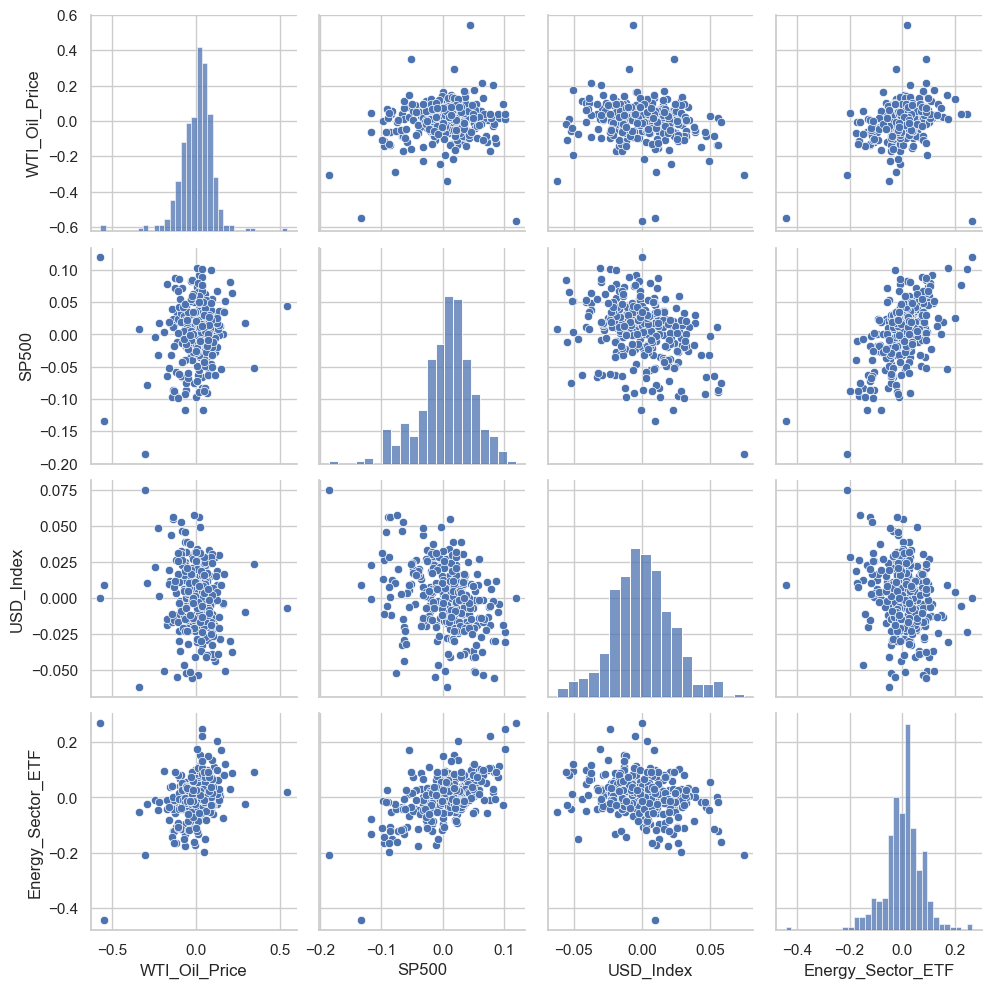

In [21]:
sns.pairplot(
    df_stationary[
        [
            'WTI_Oil_Price',
            'SP500',
            'USD_Index',
            'Energy_Sector_ETF'
        ]
    ]
)

plt.show()

### For  Bayesian Network and HMM project
Keeping the both datasets:

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_hmm = pd.DataFrame(
    scaler.fit_transform(df_stationary),
    columns=df_stationary.columns,
    index=df_stationary.index
)

print(df_hmm.head())

            WTI_Oil_Price  Industrial_Production  CPI_Energy  \
2000-02-01       0.712566               0.239485    0.927292   
2000-03-01       0.137783               0.276937    1.333612   
2000-04-01      -1.507776               0.484202   -0.992968   
2000-05-01       1.054252               0.203475   -0.347110   
2000-06-01       0.947243               0.002430    1.647985   

            Cap_Util_Oil_Gas     SP500  USD_Index  Energy_Sector_ETF  
2000-02-01         -0.023904 -0.581379   0.347621          -0.650445  
2000-03-01          0.298135  1.969577  -0.196863           1.491196  
2000-04-01         -0.300968 -0.829754   1.982818          -0.265963  
2000-05-01          0.100352 -0.623181  -0.570340           1.451688  
2000-06-01          0.218088  0.414316  -0.789192          -0.897818  


In [23]:
df_sterilized   # cleaned original levels
df_stationary   # log-differenced returns

,WTI_Oil_Price,Industrial_Production,CPI_Energy,Cap_Util_Oil_Gas,SP500,USD_Index,Energy_Sector_ETF
2000-02-01,0.076811,0.003118,0.032509,-0.000554,-0.020313,0.007486,-0.043256
2000-03-01,0.018231,0.003549,0.045257,0.007415,0.092324,-0.004542,0.113926
2000-04-01,-0.149478,0.005935,-0.027734,-0.007410,-0.031280,0.043610,-0.015038
2000-05-01,0.111634,0.002704,-0.007472,0.002521,-0.022159,-0.012793,0.111026
2000-06-01,0.100729,0.000390,0.055119,0.005434,0.023652,-0.017627,-0.061412
...,...,...,...,...,...,...,...
2026-01-01,0.035085,-0.003658,-0.014771,-0.017621,0.013570,-0.013213,0.132608
2026-02-01,0.071809,0.008133,0.006330,0.031542,-0.008706,0.006372,0.091117
2026-03-01,0.348206,-0.003163,0.103219,-0.015712,-0.052276,0.023790,0.091205
2026-04-01,0.093338,0.008638,0.037376,-0.000260,0.099151,-0.018987,-0.026633


In [24]:
df_stationary.to_csv("df_stationary.csv")